In [8]:
# Comprehensive Clustering Analysis on wine-clustering.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("wine-clustering.csv")

# Keep numeric columns only
df_numeric = df.select_dtypes(include=[np.number])

# -----------------------------
# Standardize Variables
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

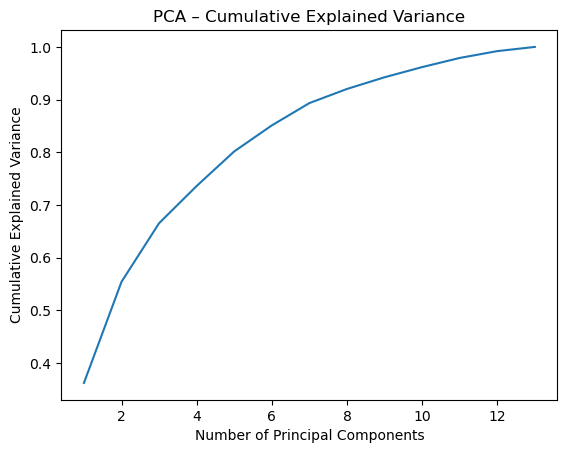

Number of components explaining at least 80% variance: 5


In [9]:
# -----------------------------
# PCA Analysis
# -----------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Determine number of components explaining >= 80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

# Plot cumulative explained variance
plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA – Cumulative Explained Variance")
plt.show()

print("Number of components explaining at least 80% variance:", n_components_80)

# Reduce data
pca_final = PCA(n_components=n_components_80)
X_reduced = pca_final.fit_transform(X_scaled)

C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Daniel\AppData\Roaming\Python\Python313\site-packages\sklearn\clust

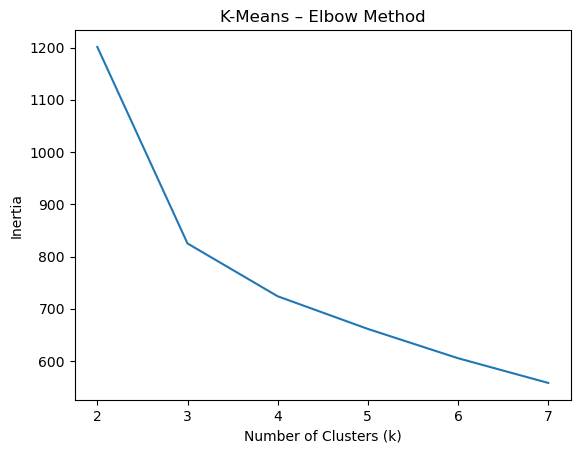

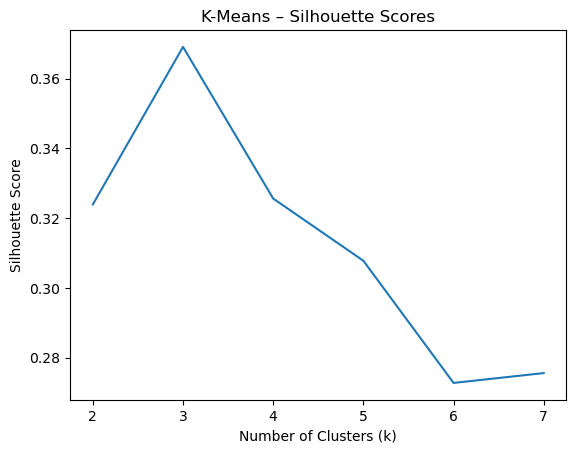

Silhouette Scores by k: {2: 0.3239172262417323, 3: 0.3690763194699229, 4: 0.32561901466893484, 5: 0.3078021391750228, 6: 0.2727790094346364, 7: 0.27559846182394077}


In [10]:
# -----------------------------
# K-Means Clustering
# -----------------------------
inertia_values = []
silhouette_scores = []
k_values = range(2, 8)

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_reduced, labels))

# Elbow plot
plt.figure()
plt.plot(k_values, inertia_values)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means – Elbow Method")
plt.show()

# Silhouette plot
plt.figure()
plt.plot(k_values, silhouette_scores)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("K-Means – Silhouette Scores")
plt.show()

print("Silhouette Scores by k:", dict(zip(k_values, silhouette_scores)))

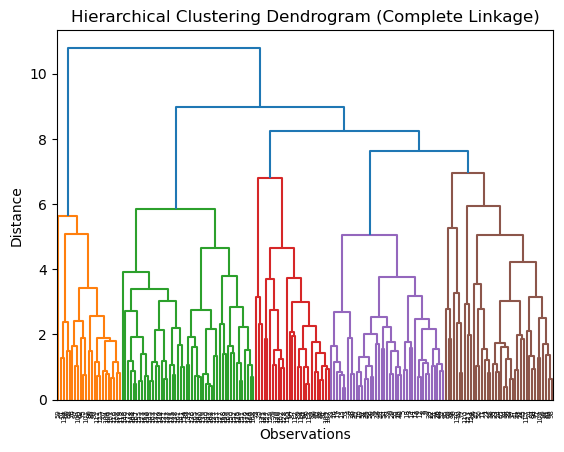

In [11]:
# -----------------------------
# Hierarchical Clustering
# -----------------------------
Z = linkage(X_reduced, method='complete', metric='euclidean')

plt.figure()
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()